# Projeto COVID-19: Classificação de Risco de Óbito
Este notebook implementa todo o fluxo do projeto seguindo o SDD definido: EDA, pré-processamento, modelagem, avaliação e interpretação de modelos para prever risco de morte em pacientes com COVID-19.


## 1. Importação de bibliotecas
Carregamos bibliotecas para análise de dados, visualização, engenharia de features, modelagem e explicabilidade.


In [ ]:
# Importa funções de sistema e tratamento de caminhos para localizar arquivos
from pathlib import Path

# Evita avisos de execução que não afetam o resultado do experimento
import warnings

# Bibliotecas para análise, visualização e manipulação de dados
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import missingno as msno

# Ferramentas de pré-processamento e modelagem para treinamento de classificadores
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, make_scorer, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils.class_weight import compute_sample_weight

# Reduz ruído na saída para manter o notebook mais limpo
warnings.filterwarnings('ignore')
# Define o estilo visual padrão dos gráficos
plt.style.use('seaborn-v0_8')

print('Bibliotecas carregadas com sucesso')


Bibliotecas carregadas com sucesso


## 2. Obtenção do dataset
Tenta-se usar um dataset local em `data/clinical_covid.csv`. Se não existir, o notebook busca o dataset Kaggle identificado.


In [2]:
# Cria a pasta de dados caso ela ainda não exista
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)
# Define o caminho esperado do arquivo CSV local
LOCAL_CSV = DATA_DIR / 'clinical_covid.csv'

# Usa o arquivo local quando ele já estiver disponível
if LOCAL_CSV.exists():
    print('Dataset local encontrado em', LOCAL_CSV)
    data_path = LOCAL_CSV
else:
    try:
        # Tenta baixar o dataset automaticamente quando o arquivo local não existe
        import kagglehub

        print('Dataset local não encontrado. Usando kagglehub para baixar o dataset...')
        dataset_path = kagglehub.dataset_download('meirnizri/covid19-dataset')
        print('Dataset baixado em', dataset_path)
        # Procura pelo primeiro CSV presente no diretório baixado
        csv_files = list(Path(dataset_path).glob('*.csv'))
        if csv_files:
            data_path = csv_files[0]
            print('Usando CSV:', data_path)
        else:
            raise FileNotFoundError('Não foi encontrado arquivo CSV no dataset baixado')
    except Exception as err:
        # Gera uma mensagem clara caso o download falhe
        raise RuntimeError('Não foi possível localizar ou baixar o dataset. Coloque o CSV em data/clinical_covid.csv') from err

print('Caminho final do dataset:', data_path)


Dataset local não encontrado. Usando kagglehub para baixar o dataset...
Dataset baixado em C:\Users\cmtel\.cache\kagglehub\datasets\meirnizri\covid19-dataset\versions\1
Usando CSV: C:\Users\cmtel\.cache\kagglehub\datasets\meirnizri\covid19-dataset\versions\1\Covid Data.csv
Caminho final do dataset: C:\Users\cmtel\.cache\kagglehub\datasets\meirnizri\covid19-dataset\versions\1\Covid Data.csv


## 3. Carregamento do DS, Análise exploratória dos dados
Verificamos shape, tipos de dados e valores ausentes para garantir que o dataset está adequado.


In [3]:
# Carrega o dataset em um DataFrame para começar a análise
df = pd.read_csv(data_path)


In [4]:
# Mostra quantas linhas e colunas existem no conjunto de dados
print('\nInformações sobre os dados:')
print(f'Número de linhas: {df.shape[0]}')
print(f'Número de colunas: {df.shape[1]}')



Informações sobre os dados:
Número de linhas: 1048575
Número de colunas: 21


In [5]:
# Exibe o tipo de cada coluna para verificar se há dados numéricos ou categóricos
print('\nTipos de dados:')
df.dtypes



Tipos de dados:



Tipos de dados:


USMER                   int64
MEDICAL_UNIT            int64
SEX                     int64
PATIENT_TYPE            int64
DATE_DIED                 str
INTUBED                 int64
PNEUMONIA               int64
AGE                     int64
PREGNANT                int64
DIABETES                int64
COPD                    int64
ASTHMA                  int64
INMSUPR                 int64
HIPERTENSION            int64
OTHER_DISEASE           int64
CARDIOVASCULAR          int64
OBESITY                 int64
RENAL_CHRONIC           int64
TOBACCO                 int64
CLASIFFICATION_FINAL    int64
ICU                     int64
dtype: object

In [6]:
# Conta quantos valores únicos cada coluna possui para identificar variáveis categóricas ou quase constantes
print('\nNúmero de valores únicos por coluna:')
df.nunique()



Número de valores únicos por coluna:


USMER                     2
MEDICAL_UNIT             13
SEX                       2
PATIENT_TYPE              2
DATE_DIED               401
INTUBED                   4
PNEUMONIA                 3
AGE                     121
PREGNANT                  4
DIABETES                  3
COPD                      3
ASTHMA                    3
INMSUPR                   3
HIPERTENSION              3
OTHER_DISEASE             3
CARDIOVASCULAR            3
OBESITY                   3
RENAL_CHRONIC             3
TOBACCO                   3
CLASIFFICATION_FINAL      7
ICU                       4
dtype: int64

In [7]:
# Resume estatísticas básicas das colunas numéricas para entender a distribuição dos dados
print('\nAnálise das estatísticas dos dados:')
df.describe()



Análise das estatísticas dos dados:



Análise das estatísticas dos dados:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
count,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06,1.048575e+06
mean,1.632194e+00,8.980565e+00,1.499259e+00,1.190765e+00,7.952288e+01,3.346831e+00,4.179410e+01,4.976558e+01,2.186404e+00,2.260569e+00,2.242626e+00,2.298132e+00,2.128989e+00,2.435143e+00,2.261810e+00,2.125176e+00,2.257180e+00,2.214333e+00,5.305653e+00,7.955397e+01
std,4.822084e-01,3.723278e+00,4.999997e-01,3.929041e-01,3.686889e+01,1.191288e+01,1.690739e+01,4.751073e+01,5.424242e+00,5.132258e+00,5.114089e+00,5.462843e+00,5.236397e+00,6.646676e+00,5.194850e+00,5.175445e+00,5.135354e+00,5.323097e+00,1.881165e+00,3.682307e+01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,1.000000e+00,4.000000e+00,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,3.000000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,9.700000e+01
50%,2.000000e+00,1.200000e+01,1.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,4.000000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,9.700000e+01
75%,2.000000e+00,1.200000e+01,2.000000e+00,1.000000e+00,9.700000e+01,2.000000e+00,5.300000e+01,9.700000e+01,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,2.000000e+00,7.000000e+00,9.700000e+01
max,2.000000e+00,1.300000e+01,2.000000e+00,2.000000e+00,9.900000e+01,9.900000e+01,1.210000e+02,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,9.800000e+01,7.000000e+00,9.900000e+01


In [8]:
# Mostra as primeiras linhas para validar rapidamente o conteúdo carregado
print('\nAmostra das top linhas:')
df.head()



Amostra das top linhas:



Amostra das top linhas:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [9]:
# Mostra as últimas linhas para conferir se o carregamento terminou corretamente
print('\nAmostra das ultimas linhas:')
df.tail()



Amostra das ultimas linhas:



Amostra das ultimas linhas:


,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
1048570,2,13,2,1,9999-99-99,97,2,40,97,2,...,2,2,2,2,2,2,2,2,7,97
1048571,1,13,2,2,9999-99-99,2,2,51,97,2,...,2,2,1,2,2,2,2,2,7,2
1048572,2,13,2,1,9999-99-99,97,2,55,97,2,...,2,2,2,2,2,2,2,2,7,97
1048573,2,13,2,1,9999-99-99,97,2,28,97,2,...,2,2,2,2,2,2,2,2,7,97
1048574,2,13,2,1,9999-99-99,97,2,52,97,2,...,2,2,2,2,2,2,2,2,7,97



Matriz de valores ausentes e Valores ausentes por coluna:



Matriz de valores ausentes e Valores ausentes por coluna:


USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64


Matriz de valores ausentes e Valores ausentes por coluna:


USMER                   0
MEDICAL_UNIT            0
SEX                     0
PATIENT_TYPE            0
DATE_DIED               0
INTUBED                 0
PNEUMONIA               0
AGE                     0
PREGNANT                0
DIABETES                0
COPD                    0
ASTHMA                  0
INMSUPR                 0
HIPERTENSION            0
OTHER_DISEASE           0
CARDIOVASCULAR          0
OBESITY                 0
RENAL_CHRONIC           0
TOBACCO                 0
CLASIFFICATION_FINAL    0
ICU                     0
dtype: int64

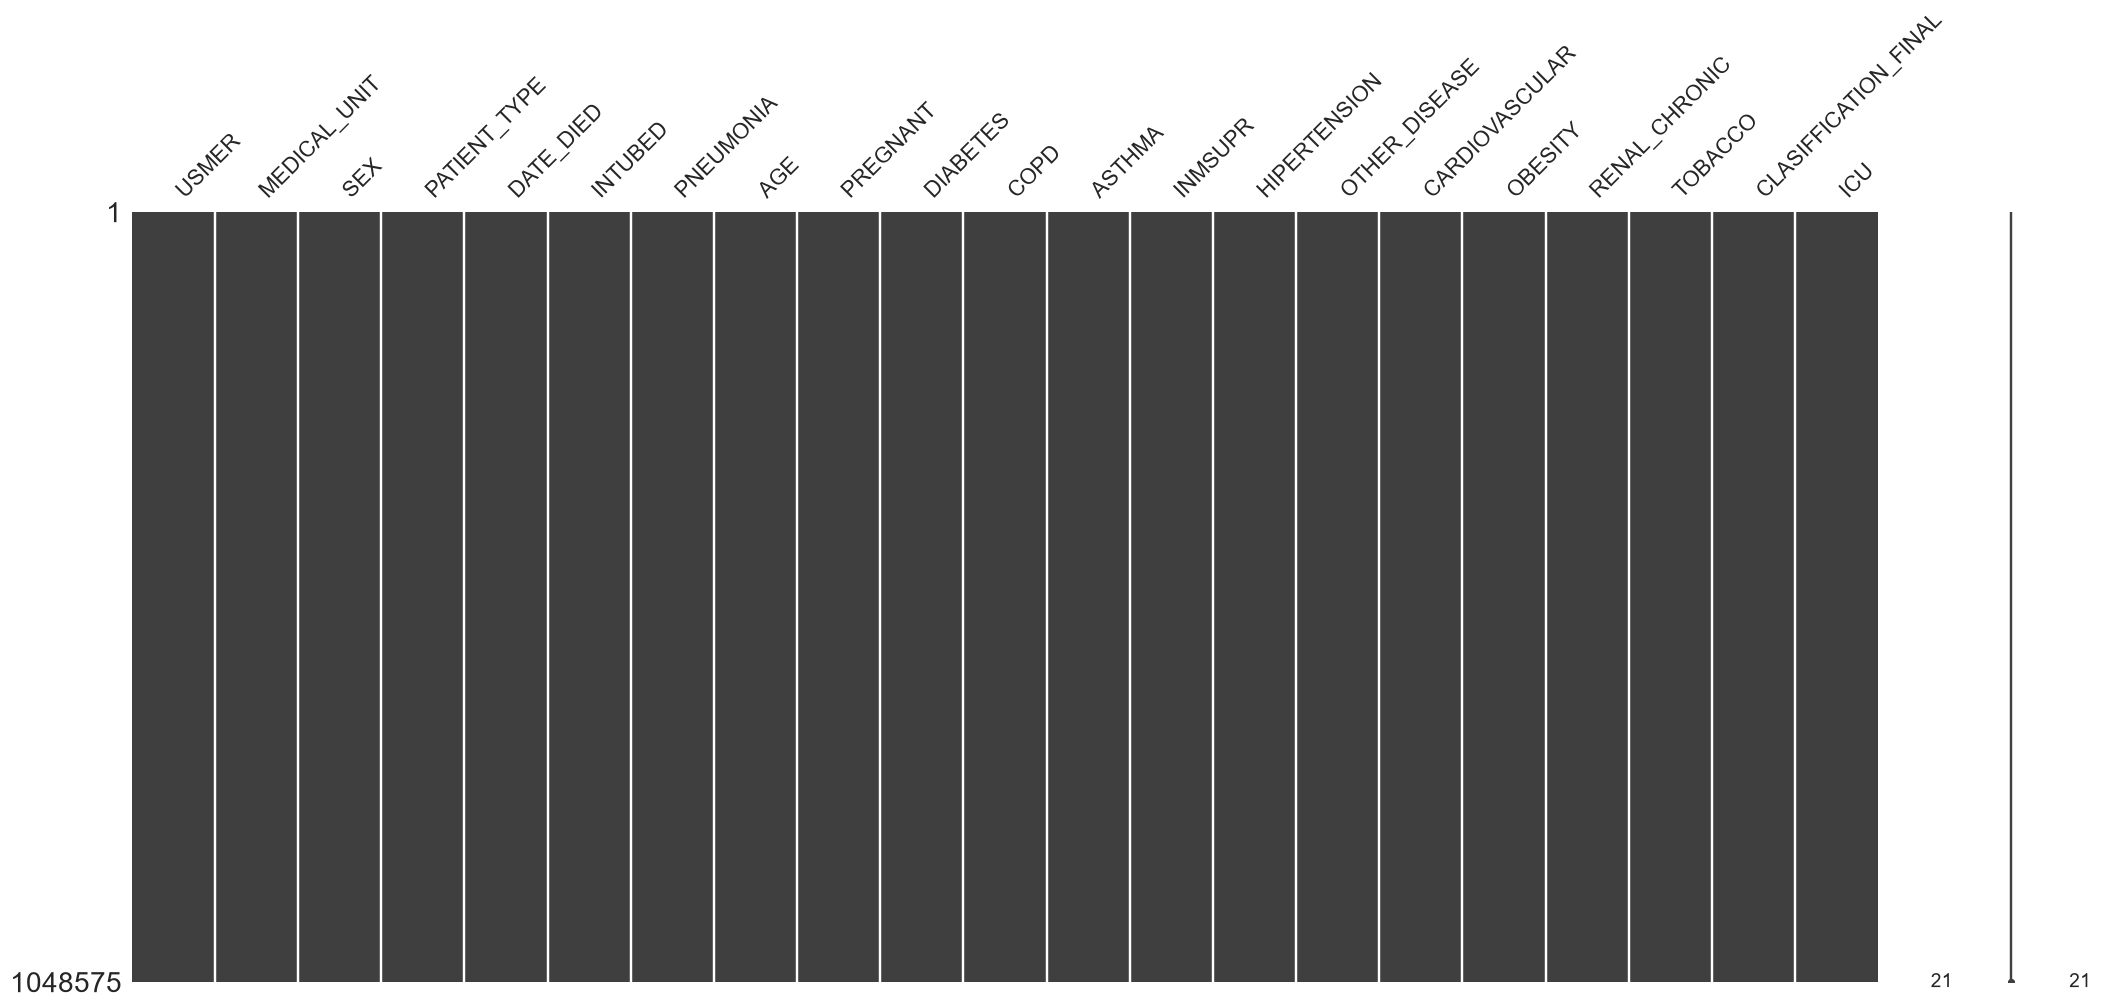

In [10]:
# Gera uma visão visual dos dados faltantes para identificar lacunas importantes
print('\nMatriz de valores ausentes e Valores ausentes por coluna:')
msno.matrix(df)

# Conta quantos registros faltam em cada coluna

df.isnull().sum().sort_values(ascending=False)


In [11]:
# Cria um dicionário com descrições em português para facilitar a interpretação das variáveis
column_descriptions = {
    'USMER': 'Unidades médicas de tratamento: 1º, 2º ou 3º nível',
    'MEDICAL_UNIT': 'Tipo de instituição do Sistema Nacional de Saúde',
    'SEX': 'Sexo: 1 para feminino e 2 para masculino',
    'PATIENT_TYPE': 'Tipo de cuidado recebido: 1 = retornou para casa; 2 = hospitalização',
    'DATE_DIED': 'Data de morte (9999-99-99 = paciente sobreviveu)',
    'INTUBED': 'Intubação (ventilador): 1 = sim; 2 = não; 97/99 = dados ausentes',
    'PNEUMONIA': 'Inflamação dos sacos de ar: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'AGE': 'Idade do paciente',
    'PREGNANT': 'Gravidez: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'DIABETES': 'Diabetes: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'COPD': 'Doença Pulmonar Obstrutiva Crônica: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'ASTHMA': 'Asma: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'INMSUPR': 'Imunosupressão: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'HIPERTENSION': 'Hipertensão: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'OTHER_DISEASE': 'Outra doença: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'CARDIOVASCULAR': 'Doença cardiovascular: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'OBESITY': 'Obesidade: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'RENAL_CHRONIC': 'Doença renal crônica: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'TOBACCO': 'Tabagismo: 1 = sim; 2 = não; 97/99 = dados ausentes',
    'CLASIFFICATION_FINAL': 'Classificação do teste COVID: 1-3 = paciente diagnosticado com COVID em diferentes graus; 4+ = não portador ou teste inconclusivo',
    'ICU': 'Admissão em UTI: 1 = sim; 2 = não; 97/99 = dados ausentes',
}

# Imprime cada coluna junto com seu tipo e descrição em português
print('\nTipos de dados e descrições:')
print('-' * 100)
for col in df.columns:
    dtype = str(df[col].dtype)
    desc = column_descriptions.get(col, 'Descrição não disponível')
    print(f'{col:<20} | {dtype:<15} | {desc}')
print('-' * 100)



Tipos de dados e descrições:
----------------------------------------------------------------------------------------------------
USMER                | int64           | Unidades médicas de tratamento: 1º, 2º ou 3º nível
MEDICAL_UNIT         | int64           | Tipo de instituição do Sistema Nacional de Saúde
SEX                  | int64           | Sexo: 1 para feminino e 2 para masculino
PATIENT_TYPE         | int64           | Tipo de cuidado recebido: 1 = retornou para casa; 2 = hospitalização
DATE_DIED            | str             | Data de morte (9999-99-99 = paciente sobreviveu)
INTUBED              | int64           | Intubação (ventilador): 1 = sim; 2 = não; 97/99 = dados ausentes
PNEUMONIA            | int64           | Inflamação dos sacos de ar: 1 = sim; 2 = não; 97/99 = dados ausentes
AGE                  | int64           | Idade do paciente
PREGNANT             | int64           | Gravidez: 1 = sim; 2 = não; 97/99 = dados ausentes
DIABETES             | int64          

## 3.1. Criação da coluna alvo: "outcome"
Criamos uma nova coluna binária que indica se o paciente faleceu. A data 9999-99-99 indica que o paciente sobreviveu (0), qualquer outra data indica óbito (1).


In [12]:
# Cria a coluna alvo binária indicando se o paciente faleceu ou não
# O valor 9999-99-99 representa sobrevivência, então qualquer outro valor indica óbito
df['OUTCOME'] = (df['DATE_DIED'] != '9999-99-99').astype(int)

# Mostra a distribuição da nova variável alvo para validar a regra de negócio
print('Coluna "outcome" criada com sucesso!')
print('\nDistribuição da coluna "outcome":')
print(df['OUTCOME'].value_counts())
print('\nProporção:')
print(df['OUTCOME'].value_counts(normalize=True))

# Exibe exemplos para confirmar a transformação aplicada aos dados
print('\nExemplos de date_died e outcome:')
print(df[['DATE_DIED', 'OUTCOME']].drop_duplicates().head(10))


Coluna "outcome" criada com sucesso!

Distribuição da coluna "outcome":
OUTCOME
0    971633
1     76942
Name: count, dtype: int64

Proporção:
OUTCOME
0    0.926622
1    0.073378
Name: proportion, dtype: float64

Exemplos de date_died e outcome:
      DATE_DIED  OUTCOME
0    03/05/2020        1
1    03/06/2020        1
2    09/06/2020        1
3    12/06/2020        1
4    21/06/2020        1
5    9999-99-99        0
151  26/02/2020        1
152  05/04/2020        1
153  08/05/2020        1
154  20/05/2020        1


In [13]:
# Agrupa os dados pelo desfecho para comparar estatísticas entre sobreviventes e óbitos

df.groupby(['OUTCOME']).describe()


USMER                                              MEDICAL_UNIT  \
            count      mean       std  min  25%  50%  75%  max        count   
OUTCOME                                                                       
0        971633.0  1.647483  0.477754  1.0  1.0  2.0  2.0  2.0     971633.0   
1         76942.0  1.439123  0.496283  1.0  1.0  1.0  2.0  2.0      76942.0   

                   ... CLASIFFICATION_FINAL            ICU             \
             mean  ...                  75%  max     count       mean   
OUTCOME            ...                                                  
0        9.136710  ...                  7.0  7.0  971633.0  84.822239   
1        7.008747  ...                  6.0  7.0   76942.0  13.025669   

                                                 
               std  min   25%   50%   75%   max  
OUTCOME                                          
0        31.788724  1.0  97.0  97.0  97.0  99.0  
1        30.682162  1.0   2.0   2.0   2.0  99.0  

[2 rows x 160 columns]

## 4. Ajuste da variável alvo e seleção de features
Definimos a coluna de desfecho e revisamos colunas numéricas/categóricas.


In [14]:
# Define o nome da coluna alvo para o treinamento do modelo
TARGET_COLUMN = 'outcome'

# Ajusta o nome da coluna alvo caso o dataset use uma variação diferente
if TARGET_COLUMN not in df.columns:
    candidate = [col for col in df.columns if 'outcome' in col.lower() or 'death' in col.lower()]
    if candidate:
        TARGET_COLUMN = candidate[0]
        print('Ajustando coluna alvo para', TARGET_COLUMN)
    else:
        raise ValueError('Não foi possível localizar a coluna alvo no dataset')

print('Coluna alvo utilizada:', TARGET_COLUMN)

# Converte a coluna alvo para valores numéricos quando ela vier como texto
if df[TARGET_COLUMN].dtype == object:
    df[TARGET_COLUMN] = df[TARGET_COLUMN].str.lower().map({'death': 1, 'died': 1, 'expired': 1, 'yes': 1, 'y': 1, '1': 1, 'true': 1, 'survived': 0, 'alive': 0, 'no': 0, 'n': 0, '0': 0})

print('Valores únicos da variável alvo:', df[TARGET_COLUMN].unique())

# Trata códigos de ausência usados em variáveis clínicas do dataset.
# As colunas que têm referência explícita a 'dados ausentes' nas descrições recebem o mesmo tratamento.
missing_code_columns = [
    col for col in df.columns
    if col in column_descriptions and 'dados ausentes' in column_descriptions[col].lower()
]

# Separa as colunas de entrada das colunas alvo, removendo DATE_DIED (vazamento) e PATIENT_TYPE (enviesado),  MEDICAL_UNIT (não é dado relevante para o modelo)
COLS_TO_EXCLUDE = {TARGET_COLUMN, 'DATE_DIED', 'PATIENT_TYPE', 'MEDICAL_UNIT', 'SEX', 'ICU_MISSING', 'ICU', 'INTUBED', 'PREGNANT'}
features = [col for col in df.columns if col not in COLS_TO_EXCLUDE]
print('Número total de features candidatas:', len(features))
print('Colunas excluídas:', COLS_TO_EXCLUDE)



# Remove as linhas que ainda contêm valores ausentes nas features e no alvo.
# A partir daqui, o restante do notebook opera sobre um dataset já filtrado sem ausências.
df = df.dropna(subset=[*features, TARGET_COLUMN]).copy()
# print(f'Linhas após remoção de ausências: {df.shape[0]}')

# Identifica automaticamente colunas numéricas e categóricas para o pré-processamento
numerical_cols = [col for col in features if pd.api.types.is_numeric_dtype(df[col])]
categorical_cols = [col for col in features if pd.api.types.is_object_dtype(df[col]) or pd.api.types.is_bool_dtype(df[col])]

print('Colunas numéricas:', numerical_cols)
print('Colunas categóricas:', categorical_cols)


for col in missing_code_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].replace([97, 98, 99], np.nan)

# Cria um indicador explícito para casos em que ICU estava ausente.
if 'ICU' in df.columns:
    df['ICU_MISSING'] = df['ICU'].isna().astype(int)

# Verificar missing values
print('Percentual de valores ausentes por coluna:')
print((df[features].isna().mean() * 100).sort_values(ascending=False).head(15))

# print('\nColunas recodificadas como missing:')
# for col in missing_code_columns:
#     print(f'- {col}')

# print('\nDistribuição das colunas recodificadas após a limpeza:')
# for col in missing_code_columns:
#     if col in df.columns:
#         print(f'\n{col}:')
#         print(df[col].value_counts(dropna=False).to_string())
df[features].shape

Ajustando coluna alvo para OUTCOME
Coluna alvo utilizada: OUTCOME
Valores únicos da variável alvo: [1 0]
Número total de features candidatas: 14
Colunas excluídas: {'OUTCOME', 'INTUBED', 'MEDICAL_UNIT', 'PATIENT_TYPE', 'SEX', 'ICU_MISSING', 'ICU', 'PREGNANT', 'DATE_DIED'}
Colunas numéricas: ['USMER', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL']
Colunas categóricas: []
Percentual de valores ausentes por coluna:
PNEUMONIA               1.526166
OTHER_DISEASE           0.481129
INMSUPR                 0.324631
DIABETES                0.318337
TOBACCO                 0.307083
HIPERTENSION            0.296021
CARDIOVASCULAR          0.293350
OBESITY                 0.289154
RENAL_CHRONIC           0.286675
COPD                    0.286389
ASTHMA                  0.284100
USMER                   0.000000
AGE                     0.000000
CLASIFFICATION_FINAL    0.0

Ajustando coluna alvo para OUTCOME
Coluna alvo utilizada: OUTCOME
Valores únicos da variável alvo: [1 0]
Número total de features candidatas: 14
Colunas excluídas: {'OUTCOME', 'INTUBED', 'MEDICAL_UNIT', 'PATIENT_TYPE', 'SEX', 'ICU_MISSING', 'ICU', 'PREGNANT', 'DATE_DIED'}
Colunas numéricas: ['USMER', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL']
Colunas categóricas: []
Percentual de valores ausentes por coluna:
PNEUMONIA               1.526166
OTHER_DISEASE           0.481129
INMSUPR                 0.324631
DIABETES                0.318337
TOBACCO                 0.307083
HIPERTENSION            0.296021
CARDIOVASCULAR          0.293350
OBESITY                 0.289154
RENAL_CHRONIC           0.286675
COPD                    0.286389
ASTHMA                  0.284100
USMER                   0.000000
AGE                     0.000000
CLASIFFICATION_FINAL    0.0

(1048575, 14)

## 5. EDA exploratória
Visualizamos distribuições, proporção de classes e correlações para extrair insights clínicos.


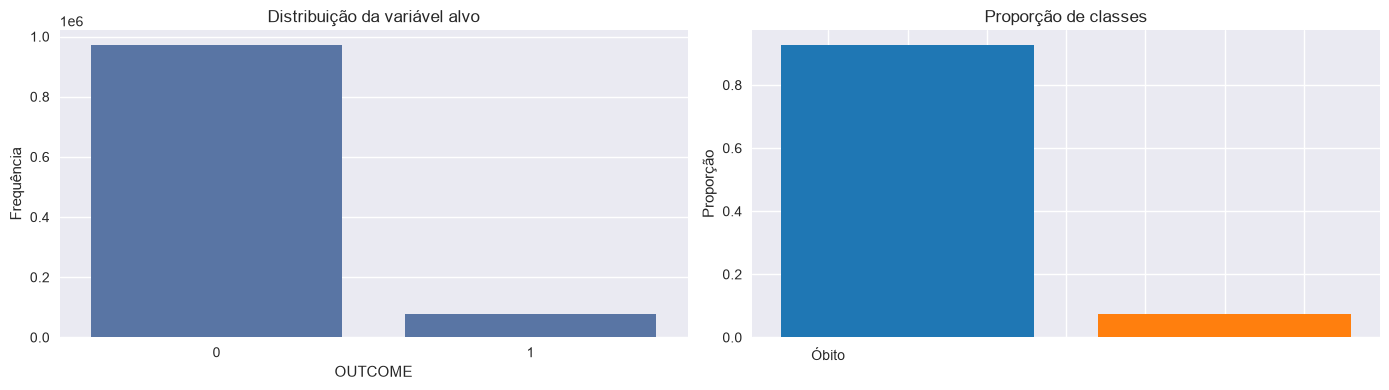

Proporção de classes:
OUTCOME
0    0.926622
1    0.073378
Name: proportion, dtype: float64


In [15]:
# Análise visual compacta do desbalanceamento e correlações principais
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribuição e proporção das classes
sns.countplot(x=TARGET_COLUMN, data=df, ax=axes[0])
axes[0].set_title('Distribuição da variável alvo')
axes[0].set_ylabel('Frequência')

# Proporção das classes
props = df[TARGET_COLUMN].value_counts(normalize=True)
axes[1].bar(props.index, props.values, color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('Proporção de classes')
axes[1].set_ylabel('Proporção')
axes[1].set_xticklabels(['Sobreviveu', 'Óbito'], rotation=0)

plt.tight_layout()
plt.show()

print('Proporção de classes:')
print(df[TARGET_COLUMN].value_counts(normalize=True))

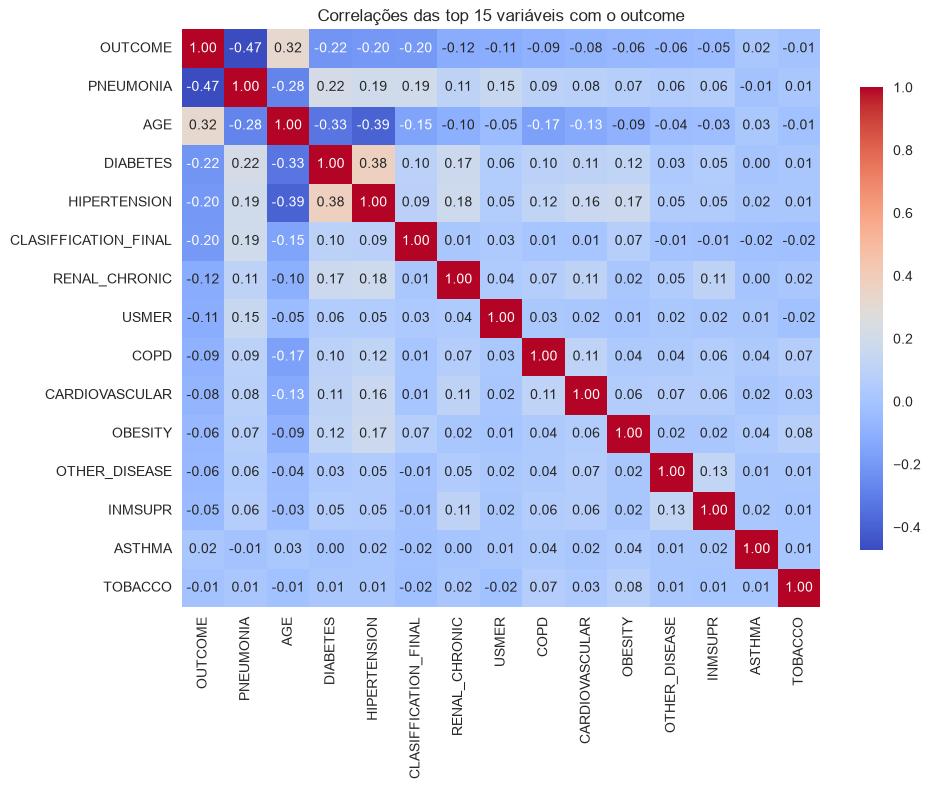

In [16]:
# Matriz de correlação com as variáveis numéricas mais relevantes
numeric_cols_for_corr = numerical_cols.copy()
if TARGET_COLUMN in numeric_cols_for_corr:
    numeric_cols_for_corr.remove(TARGET_COLUMN)

corr_df = df[numeric_cols_for_corr + [TARGET_COLUMN]].copy()
corr_df[TARGET_COLUMN] = corr_df[TARGET_COLUMN].astype(int)

# Seleciona apenas as colunas com maior correlação com o alvo para evitar poluição visual
corr_with_target = corr_df.corr()[TARGET_COLUMN].abs().sort_values(ascending=False).head(15)
selected_for_corr = list(corr_with_target.index)

corr_matrix = corr_df[selected_for_corr].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', cbar_kws={'shrink': .8})
plt.title('Correlações das top 15 variáveis com o outcome')
plt.tight_layout()
plt.show()

## 6. Pré-processamento
Montamos um pipeline com imputação, codificação one-hot e padronização. Isso garante reprodutibilidade e limpeza correta dos dados.


In [17]:
# Cria um pipeline para preencher valores ausentes e transformar dados antes do treino
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Trata colunas categóricas com preenchimento e codificação one-hot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

# Combina as transformações numéricas e categóricas em um único pré-processador
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols),
], remainder='drop')

print('Pipeline de pré-processamento criado com sucesso')

# Mostra quais colunas foram realmente usadas pelo pré-processador
print('Colunas incluídas no pré-processador:')
print(numerical_cols + categorical_cols)


Pipeline de pré-processamento criado com sucesso
Colunas incluídas no pré-processador:
['USMER', 'PNEUMONIA', 'AGE', 'DIABETES', 'COPD', 'ASTHMA', 'INMSUPR', 'HIPERTENSION', 'OTHER_DISEASE', 'CARDIOVASCULAR', 'OBESITY', 'RENAL_CHRONIC', 'TOBACCO', 'CLASIFFICATION_FINAL']


In [18]:
# Separa os dados em treino, validação e teste mantendo a proporção das classes
X = df[numerical_cols + categorical_cols]
y = df[TARGET_COLUMN].astype(int)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.2, stratify=y_train_val, random_state=42
)

# Calcula pesos por amostra para dar maior importância à classe minoritária (óbitos)
sample_weights_train = compute_sample_weight('balanced', y_train)

print('Shapes:')
print('X_train', X_train.shape)
print('X_val', X_val.shape)
print('X_test', X_test.shape)
print('Pesos de classe aplicados ao treino.')


Shapes:
X_train (671088, 14)
X_val (167772, 14)
X_test (209715, 14)
Pesos de classe aplicados ao treino.


## 7. Modelagem
Aqui usamos validação cruzada para buscar hiperparâmetros robustos e avaliar os modelos em diferentes particionamentos do conjunto de treino. A validação cruzada stratificada (`StratifiedKFold`) mantém a proporção de classes em cada divisão e ajuda a reduzir o overfitting. Para este problema de risco de óbito, priorizamos `recall` na escolha do melhor modelo, já que detectar casos positivos é crítico.


Os modelos avaliados são:

- Regressão Logística- XGBoost (se disponível)

- Árvore de Decisão- Random Forest

XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


...


Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



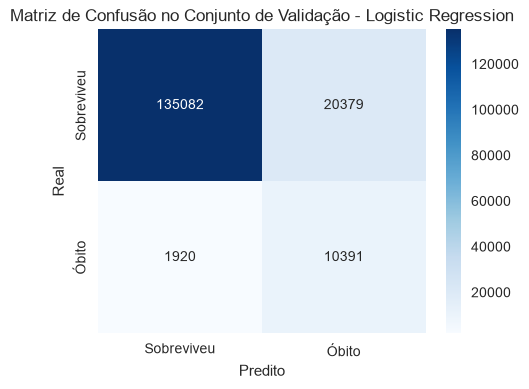

XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



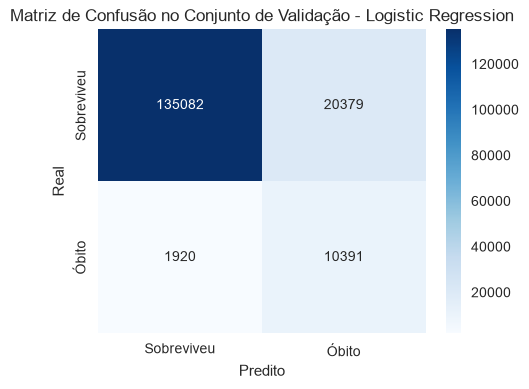

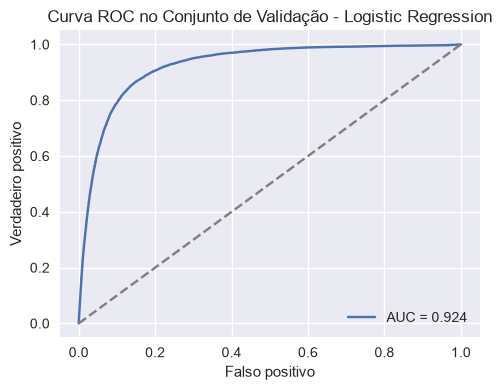

XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



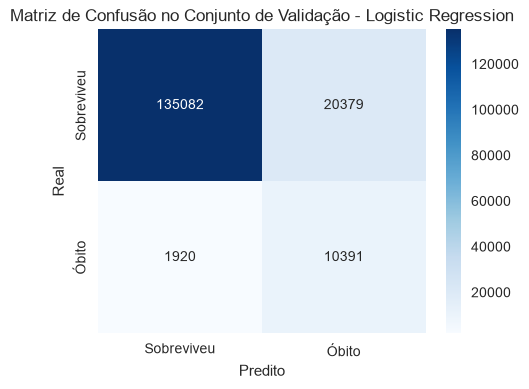

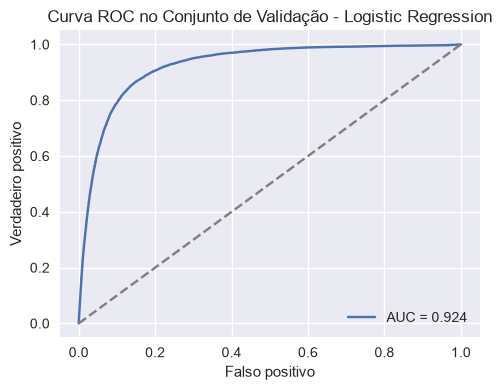

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



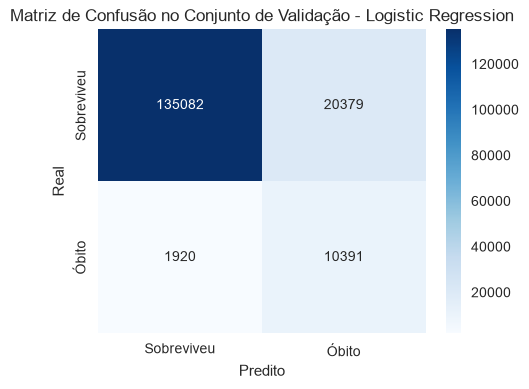

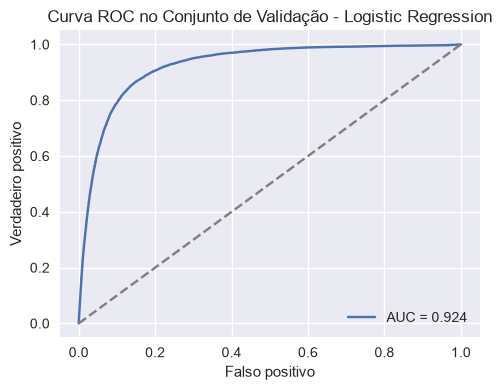

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


...


Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



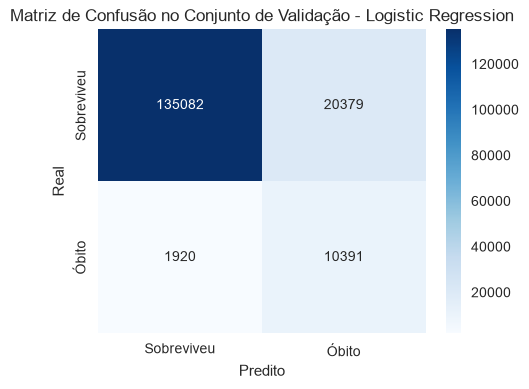

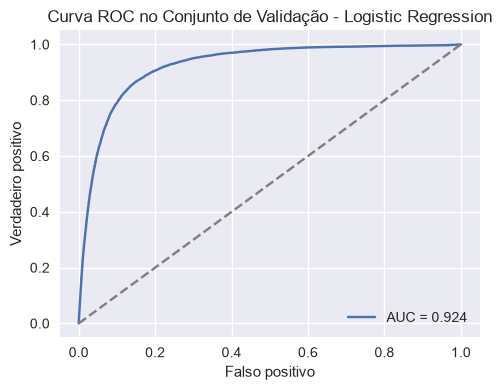

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


...


Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



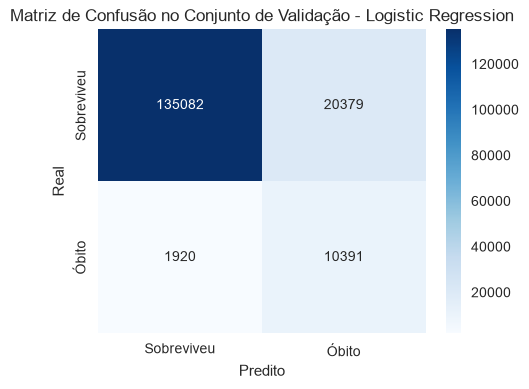

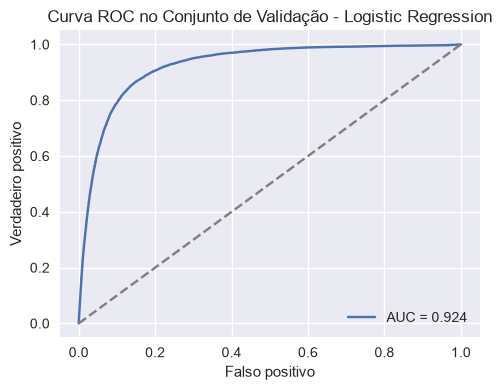

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


...


Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



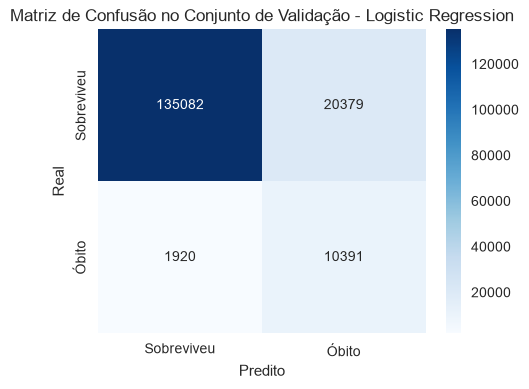

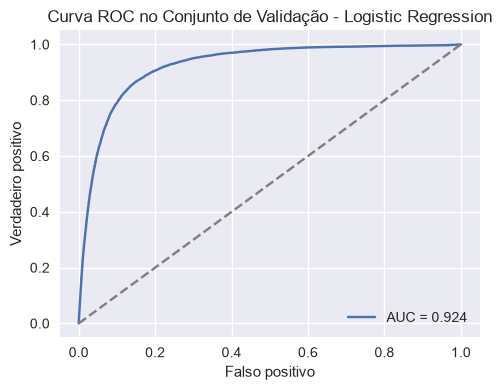

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
44,0.265322,0.001947,0.909144,0.875453,0.265322,"{'classifier__criterion': 'entropy', 'classifi..."
8,0.265183,0.001987,0.909713,0.875811,0.265183,"{'classifier__criterion': 'gini', 'classifier_..."
42,0.265041,0.002044,0.906565,0.873504,0.265041,"{'classifier__criterion': 'entropy', 'classifi..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.9862 ± 0.0008
  recall validação médio: 0.9788 ± 0.0009

Desempenho no conjunto de validação:
                      Decision Tree
validation_accuracy        0.537074
validation_recall          0.982942
validation_precision       0.135121
validation_f1              0.237582
validation_roc_auc         0.926844

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       1.00      0.50      0.67    155461
       Óbito       0.14      0.98      0.24     12311

    accuracy                           0.54    167772
   macro avg       0.57      0.74      0.45    167772
weighted avg       0.93      0.54      0.64    167772



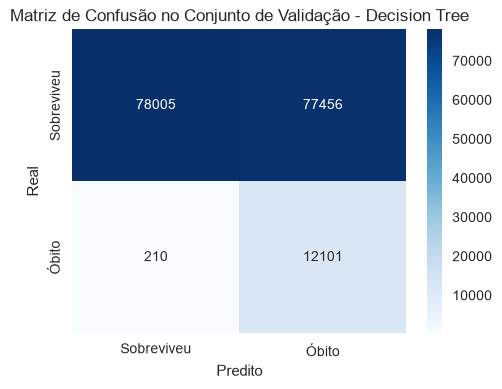

XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



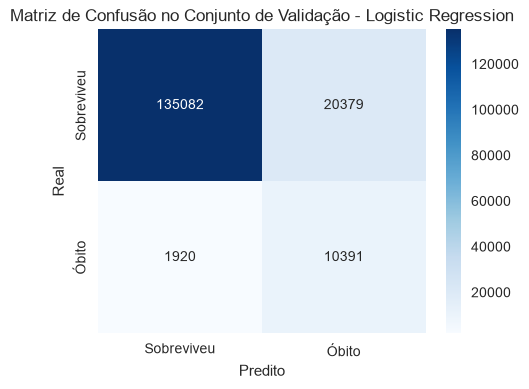

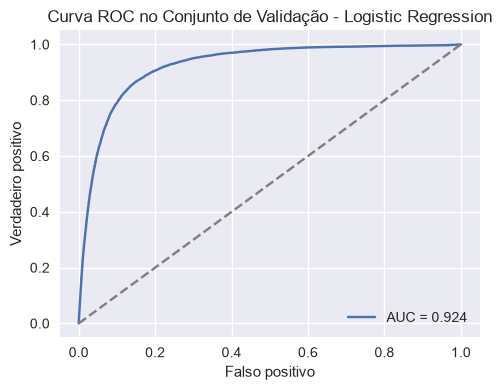

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
44,0.265322,0.001947,0.909144,0.875453,0.265322,"{'classifier__criterion': 'entropy', 'classifi..."
8,0.265183,0.001987,0.909713,0.875811,0.265183,"{'classifier__criterion': 'gini', 'classifier_..."
42,0.265041,0.002044,0.906565,0.873504,0.265041,"{'classifier__criterion': 'entropy', 'classifi..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.9862 ± 0.0008
  recall validação médio: 0.9788 ± 0.0009

Desempenho no conjunto de validação:
                      Decision Tree
validation_accuracy        0.537074
validation_recall          0.982942
validation_precision       0.135121
validation_f1              0.237582
validation_roc_auc         0.926844

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       1.00      0.50      0.67    155461
       Óbito       0.14      0.98      0.24     12311

    accuracy                           0.54    167772
   macro avg       0.57      0.74      0.45    167772
weighted avg       0.93      0.54      0.64    167772



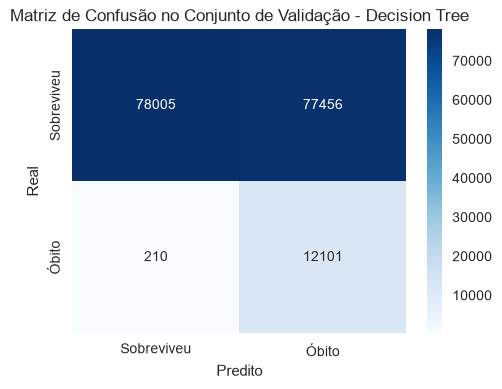

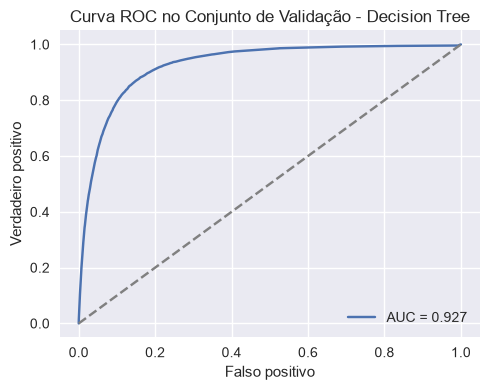

XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



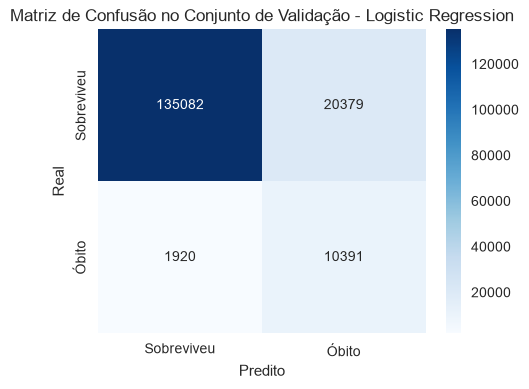

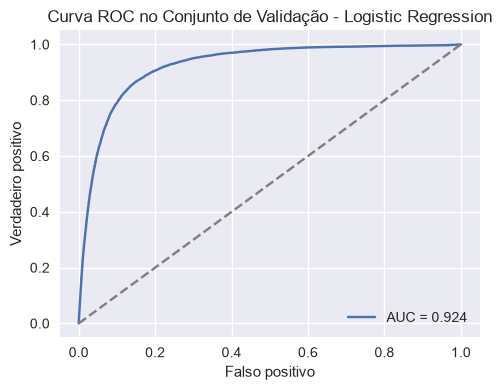

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
44,0.265322,0.001947,0.909144,0.875453,0.265322,"{'classifier__criterion': 'entropy', 'classifi..."
8,0.265183,0.001987,0.909713,0.875811,0.265183,"{'classifier__criterion': 'gini', 'classifier_..."
42,0.265041,0.002044,0.906565,0.873504,0.265041,"{'classifier__criterion': 'entropy', 'classifi..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.9862 ± 0.0008
  recall validação médio: 0.9788 ± 0.0009

Desempenho no conjunto de validação:
                      Decision Tree
validation_accuracy        0.537074
validation_recall          0.982942
validation_precision       0.135121
validation_f1              0.237582
validation_roc_auc         0.926844

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       1.00      0.50      0.67    155461
       Óbito       0.14      0.98      0.24     12311

    accuracy                           0.54    167772
   macro avg       0.57      0.74      0.45    167772
weighted avg       0.93      0.54      0.64    167772



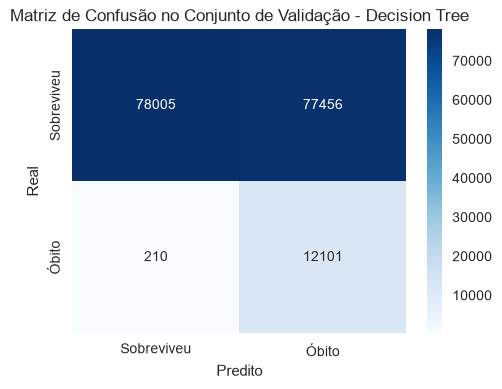

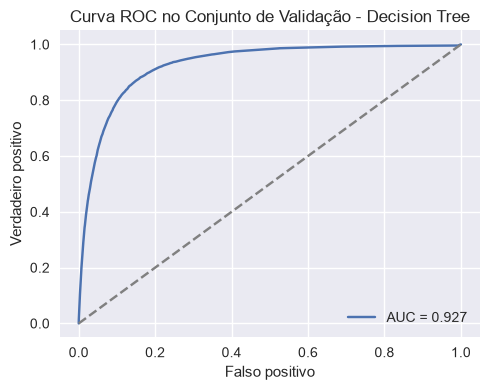

Fitting 5 folds for each of 72 candidates, totalling 360 fits


XGBoost scale_pos_weight calculado: 12.628
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Resumo da validação cruzada para Logistic Regression
Melhor resultado de recall (CV): 0.8445 ± 0.0025
Melhor resultado de ROC AUC (CV): 0.9234 ± 0.0006
Melhor resultado de F1 (CV): 0.4810 ± 0.0018
Melhores parâmetros:
  classifier__C: 0.01
  classifier__penalty: l2
  classifier__solver: liblinear

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.844526,0.002477,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.844485,0.002457,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."
3,0.844465,0.002458,0.844465,0.923345,0.481160,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
0,0.923351,0.000568,0.844526,0.923351,0.480969,"{'classifier__C': 0.01, 'classifier__penalty':..."
1,0.923348,0.000569,0.844445,0.923348,0.481129,"{'classifier__C': 0.01, 'classifier__penalty':..."
2,0.923346,0.000570,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
6,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 10.0, 'classifier__penalty':..."
4,0.481168,0.001795,0.844465,0.923345,0.481168,"{'classifier__C': 1.0, 'classifier__penalty': ..."
2,0.481166,0.001800,0.844485,0.923346,0.481166,"{'classifier__C': 0.1, 'classifier__penalty': ..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.8446 ± 0.0005
  recall validação médio: 0.8445 ± 0.0025

Desempenho no conjunto de validação:
                      Logistic Regression
validation_accuracy              0.867087
validation_recall                0.844042
validation_precision             0.337699
validation_f1                    0.482394
validation_roc_auc               0.924267

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       0.99      0.87      0.92    155461
       Óbito       0.34      0.84      0.48     12311

    accuracy                           0.87    167772
   macro avg       0.66      0.86      0.70    167772
weighted avg       0.94      0.87      0.89    167772



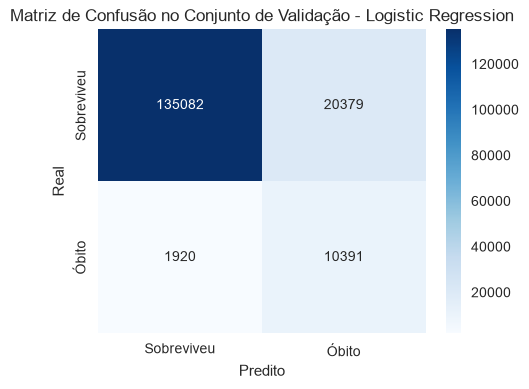

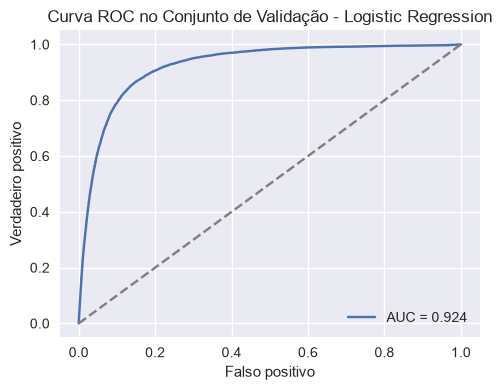

Fitting 5 folds for each of 72 candidates, totalling 360 fits

Resumo da validação cruzada para Decision Tree
Melhor resultado de recall (CV): 0.9788 ± 0.0009
Melhor resultado de ROC AUC (CV): 0.9229 ± 0.0008
Melhor resultado de F1 (CV): 0.2398 ± 0.0044
Melhores parâmetros:
  classifier__criterion: gini
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__min_samples_split: 10

Top 3 combinações por recall na CV:


,mean_test_recall,std_test_recall,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.978819,0.000871,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.978738,0.000845,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por roc_auc na CV:


,mean_test_roc_auc,std_test_roc_auc,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
26,0.922900,0.000794,0.978819,0.922900,0.239839,"{'classifier__criterion': 'gini', 'classifier_..."
24,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."
25,0.922831,0.000772,0.978738,0.922831,0.239818,"{'classifier__criterion': 'gini', 'classifier_..."



Top 3 combinações por f1 na CV:


,mean_test_f1,std_test_f1,mean_test_recall,mean_test_roc_auc,mean_test_f1,params
44,0.265322,0.001947,0.909144,0.875453,0.265322,"{'classifier__criterion': 'entropy', 'classifi..."
8,0.265183,0.001987,0.909713,0.875811,0.265183,"{'classifier__criterion': 'gini', 'classifier_..."
42,0.265041,0.002044,0.906565,0.873504,0.265041,"{'classifier__criterion': 'entropy', 'classifi..."


Comparação treino vs. validação para recall:
  recall treino médio: 0.9862 ± 0.0008
  recall validação médio: 0.9788 ± 0.0009

Desempenho no conjunto de validação:
                      Decision Tree
validation_accuracy        0.537074
validation_recall          0.982942
validation_precision       0.135121
validation_f1              0.237582
validation_roc_auc         0.926844

Relatório de classificação na validação:
              precision    recall  f1-score   support

  Sobreviveu       1.00      0.50      0.67    155461
       Óbito       0.14      0.98      0.24     12311

    accuracy                           0.54    167772
   macro avg       0.57      0.74      0.45    167772
weighted avg       0.93      0.54      0.64    167772



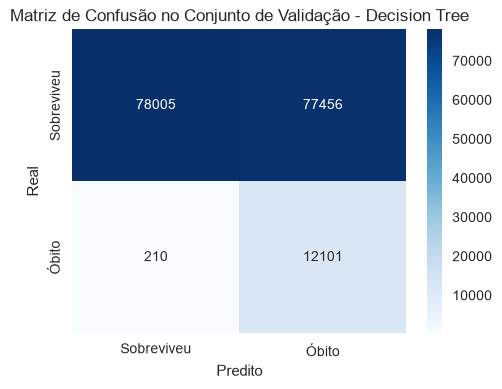

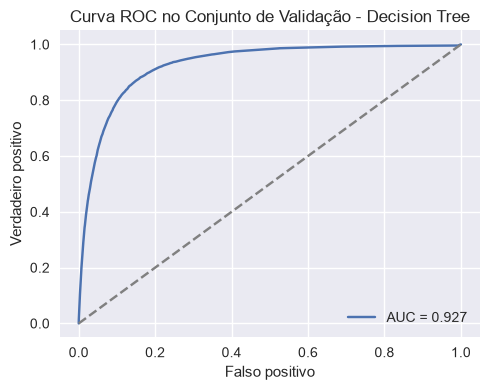

Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 

In [ ]:
# Versão mais rápida mantendo vários modelos
models = {
    'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=500, random_state=42),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42, max_depth=8),
    'Random Forest': RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=60, max_depth=8, n_jobs=1),
    'Extra Trees': ExtraTreesClassifier(class_weight='balanced', random_state=42, n_estimators=60, max_depth=8, n_jobs=1),
}

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.1, 1.0],
        'classifier__solver': ['liblinear'],
    },
    'Decision Tree': {
        'classifier__criterion': ['gini'],
        'classifier__max_depth': [5, 8],
        'classifier__min_samples_leaf': [1, 2],
    },
    'Random Forest': {
        'classifier__n_estimators': [60],
        'classifier__max_depth': [8, None],
        'classifier__min_samples_leaf': [1, 2],
        'classifier__max_features': ['sqrt'],
    },
    'Extra Trees': {
        'classifier__n_estimators': [60],
        'classifier__max_depth': [8, None],
        'classifier__min_samples_leaf': [1, 2],
        'classifier__max_features': ['sqrt'],
    },
}

scoring = {
    'roc_auc': 'roc_auc',
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
}

model_results = []

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grids[name],
        scoring=scoring,
        refit='recall',
        cv=cv,
        n_jobs=1,
        return_train_score=False,
        verbose=0,
    )

    grid_search.fit(X_train, y_train, classifier__sample_weight=sample_weights_train)

    best_pipeline = grid_search.best_estimator_
    y_val_pred = best_pipeline.predict(X_val)
    y_val_proba = best_pipeline.predict_proba(X_val)[:, 1] if hasattr(best_pipeline, 'predict_proba') else None

    metrics = {
        'model': name,
        'validation_accuracy': accuracy_score(y_val, y_val_pred),
        'validation_recall': recall_score(y_val, y_val_pred),
        'validation_precision': precision_score(y_val, y_val_pred),
        'validation_f1': f1_score(y_val, y_val_pred),
        'validation_roc_auc': roc_auc_score(y_val, y_val_proba) if y_val_proba is not None else np.nan,
        'best_params': grid_search.best_params_,
    }
    model_results.append(metrics)

    print(f"{name}: recall={metrics['validation_recall']:.3f} | ROC-AUC={metrics['validation_roc_auc']:.3f}")

summary_df = pd.DataFrame(model_results)
print('\nResumo consolidado de desempenho por modelo:')
print(summary_df.sort_values('validation_recall', ascending=False).to_string(index=False))


In [ ]:
# Re-treina o melhor modelo no conjunto treino+validação usando configuração simples
best_model_name = summary_df.sort_values(['validation_recall', 'validation_roc_auc'], ascending=False).iloc[0]['model']
best_params = summary_df.sort_values(['validation_recall', 'validation_roc_auc'], ascending=False).iloc[0]['best_params']

print('Melhor modelo selecionado:', best_model_name)
print('Hiperparâmetros:', best_params)

best_model = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=500, random_state=42, solver='liblinear', C=best_params.get('classifier__C', 1.0)
    ),
    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced', random_state=42, max_depth=best_params.get('classifier__max_depth', 8),
        criterion=best_params.get('classifier__criterion', 'gini'),
        min_samples_leaf=best_params.get('classifier__min_samples_leaf', 1)
    ),
    'Random Forest': RandomForestClassifier(
        class_weight='balanced', random_state=42, n_estimators=60, max_depth=best_params.get('classifier__max_depth', 8),
        min_samples_leaf=best_params.get('classifier__min_samples_leaf', 1), max_features=best_params.get('classifier__max_features', 'sqrt')
    ),
    'Extra Trees': ExtraTreesClassifier(
        class_weight='balanced', random_state=42, n_estimators=60, max_depth=best_params.get('classifier__max_depth', 8),
        min_samples_leaf=best_params.get('classifier__min_samples_leaf', 1), max_features=best_params.get('classifier__max_features', 'sqrt')
    ),
}[best_model_name]

best_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', best_model)])
sample_weights_train_val = compute_sample_weight('balanced', y_train_val)
best_pipeline.fit(X_train_val, y_train_val, classifier__sample_weight=sample_weights_train_val)
print('Retreinamento concluído no conjunto combinado de treino/validação')


Scale_pos_weight para re-treinamento: 2.221
Melhor modelo para re-treinamento: XGBoost
Usando os melhores parâmetros observados: {'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 200, 'classifier__subsample': 0.7}
Retreinamento concluído no conjunto combinado de treino/validação


## 8. Avaliação final no conjunto de teste
Usamos o melhor modelo de validação para avaliar o desempenho no conjunto de teste. A métrica de recall ganha prioridade para risco de morte.


Melhor modelo selecionado para avaliação final: XGBoost
Métricas de teste:
  accuracy: 0.7569
  recall: 0.7219
  precision: 0.5884
  f1: 0.6483
  roc_auc: 0.8322


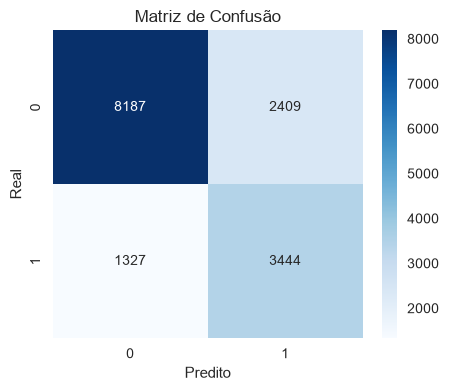

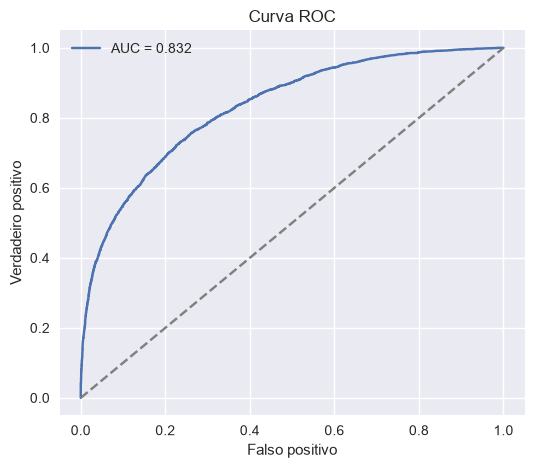

In [ ]:
# Avalia o modelo final no conjunto de teste, que não foi usado durante o treinamento
print('Melhor modelo selecionado para avaliação final:', best_model_name)

# Usa o pipeline já configurado e retreinado no passo anterior

y_test_pred = best_pipeline.predict(X_test)
y_test_proba = best_pipeline.predict_proba(X_test)[:, 1] if hasattr(best_pipeline, 'predict_proba') else None

# Calcula métricas de desempenho no conjunto reservado para teste
test_metrics = {
    'accuracy': accuracy_score(y_test, y_test_pred),
    'recall': recall_score(y_test, y_test_pred),
    'precision': precision_score(y_test, y_test_pred),
    'f1': f1_score(y_test, y_test_pred),
    'roc_auc': roc_auc_score(y_test, y_test_proba) if y_test_proba is not None else np.nan,
}

print('Métricas de teste:')
for metric_name, metric_value in test_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

# Gera a matriz de confusão para visualizar erros de classificação
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Plota a curva ROC quando o modelo fornece probabilidade de classe positiva
if y_test_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_test_proba)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_test_proba):.3f}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel('Falso positivo')
    plt.ylabel('Verdadeiro positivo')
    plt.title('Curva ROC')
    plt.legend()
    plt.show()


## 9. Interpretação do modelo
Apresentamos a importância de features para entender quais variáveis influenciam a previsão de risco de óbito.


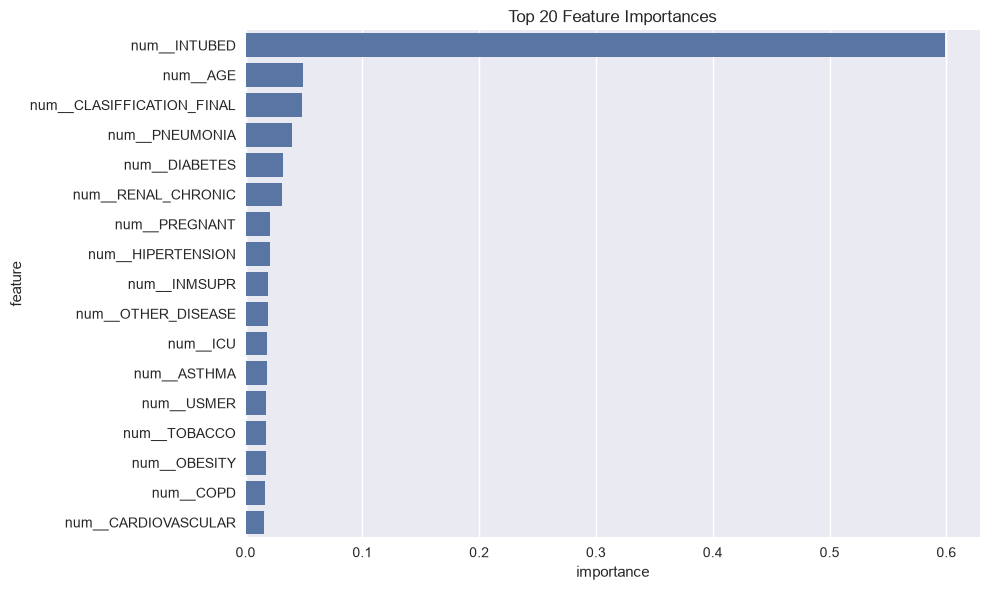

Background dataset has 15367 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=15367 when initializing the masker.


                      feature  importance
1                num__INTUBED    0.598803
3                    num__AGE    0.049381
15  num__CLASIFFICATION_FINAL    0.048068
2              num__PNEUMONIA    0.039932
5               num__DIABETES    0.031940
13         num__RENAL_CHRONIC    0.030909
4               num__PREGNANT    0.020619
9           num__HIPERTENSION    0.020500
8                num__INMSUPR    0.019541
10         num__OTHER_DISEASE    0.018819
16                   num__ICU    0.018740
7                 num__ASTHMA    0.017986
0                  num__USMER    0.017761
14               num__TOBACCO    0.017453
12               num__OBESITY    0.017366
6                   num__COPD    0.016492
11        num__CARDIOVASCULAR    0.015689
SHAP não pôde ser executado: Categorical split is not yet supported. You can still use TreeExplainer with `feature_perturbation=tree_path_dependent`.


In [ ]:
# Extrai o classificador treinado para analisar a importância das variáveis
classifier = best_pipeline.named_steps['classifier']

# Se o modelo expuser importância das features, exibe as mais relevantes
if hasattr(classifier, 'feature_importances_'):
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    importances = classifier.feature_importances_
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances,
    }).sort_values(by='importance', ascending=False).head(20)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='importance', y='feature', data=importance_df)
    plt.title('Top 20 Feature Importances')
    plt.tight_layout()
    plt.show()
    print(importance_df)
else:
    print('O modelo selecionado não possui atributo feature_importances_.')

# Tenta usar SHAP para explicar as predições de forma mais detalhada
try:
    import shap

    explainer = shap.Explainer(classifier, best_pipeline.named_steps['preprocessor'].transform(X_test))
    shap_values = explainer(best_pipeline.named_steps['preprocessor'].transform(X_test))

    shap.summary_plot(shap_values, feature_names=best_pipeline.named_steps['preprocessor'].get_feature_names_out(), show=False)
    plt.title('SHAP Summary Plot')
    plt.tight_layout()
    plt.show()
except Exception as e:
    print('SHAP não pôde ser executado:', e)


## 10. Conclusão
Este notebook construiu um sistema de IA para classificar risco de morte em pacientes com COVID-19, incluindo EDA, pré-processamento, modelagem e interpretação. As métricas enfatizam recall como medida principal para minimizar falsos negativos em um contexto clínico.
